### Nairobi Flood Footprints by Katie, Helen & Ezra

---
## Part 1: Data Acquisition + Preprocessing

We'll pull Sentinel-1 Level-1C Ground Range Detected (GRD) data over Nairobi from May 2024

Sentinel-1 is a pair of Synthetic Aperture Radar (SAR) imaging satellites launched in 2014 and 2016 by the European Space Agency (ESA). Their 6 day revisit cycle and ability to observe through clouds makes this dataset perfect for sea and land monitoring, emergency response due to environmental disasters, and economic applications. This dataset represents the global Sentinel-1 GRD archive, from beginning to the present, converted to cloud-optimized GeoTIFF format.

In [20]:
# Imports
from datetime import datetime, timedelta

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pystac_client
import rioxarray  # noqa: F401
import xarray as xr
from dask.distributed import Client
from matplotlib.patches import Patch
from odc.geo.geobox import GeoBox
from shapely.geometry import Polygon
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

client = Client(processes=False)

/Users/kknox/Documents/musa-650/musa-650-spring2026-Projects/FinalProjects/.venv/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58460 instead
  warnings.warn(


Aborting load due to failure while reading: s3://sentinel-s1-l1c/GRD/2024/2/7/IW/DV/S1A_IW_GRDH_1SDV_20240207T154816_20240207T154841_052454_065801_8E91/measurement/iw-vh.tiff:1
2026-04-21 17:55:52,247 - distributed.worker - ERROR - Compute Failed
Key:       ('vh-mul-93c2e7ff1f2cacede709428abcc828fa', 0, 1, 4)
State:     executing
Task:  <Task ('vh-mul-93c2e7ff1f2cacede709428abcc828fa', 0, 1, 4) _execute_subgraph(...)>
Exception: "RasterioIOError('CURL error: Could not resolve host: sentinel-s1-l1c.s3.eu-central-1.amazonaws.com')"
Traceback: '  File "/Users/kknox/Documents/musa-650/musa-650-spring2026-Projects/FinalProjects/.venv/lib/python3.13/site-packages/odc/loader/_builder.py", line 498, in _dask_loader_tyx\n    _fill_nd_slice(\n    ~~~~~~~~~~~~~~^\n        ti_srcs, gbox, cfg, chunk[ti], ydim=ydim, selection=selection\n        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n    )\n    ^\n  File "/Users/kknox/Documents/musa-650/musa-650-spring2026-Projects/FinalProjec

In [21]:
# Define spatial and temporal extent
dx = 0.0003  # ~30m resolution
epsg = 4326

# Nairobi area bounds
#-1.5371°, 36.5134° : -1.0918°, 37.2744°
latmin, latmax = -1.5371, -1.0918
lonmin, lonmax = 36.5134, 37.2744
bounds = (lonmin, latmin, lonmax, latmax)

# Temporal extent: May 2026
#start_date = datetime(year=2026, month=3, day=1)
#end_date = start_date + timedelta(days=20)

# Temporal extent: April 2024
start_date = datetime(year=2024, month=2, day=1)
end_date = start_date + timedelta(days=180)

time_format = "%Y-%m-%d"
date_query = f"{start_date.strftime(time_format)}/{end_date.strftime(time_format)}"

# Search for Sentinel-2 data
items = (
    pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    .search(
        bbox=bounds,
        collections=["sentinel-1-grd"],
        datetime=date_query,
        limit=100,
        query={"sar:instrument_mode": {"in": ["IW"]}},
    )
    .item_collection()
)
print(f"{len(items)} scenes found")


30 scenes found


In [30]:
import os
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'
os.environ['GDAL_HTTP_MERGE_CONSECUTIVE_RANGES'] = 'YES'
os.environ['GDAL_HTTP_TIMEOUT'] = '300'
os.environ['GDAL_HTTP_MAX_RETRY'] = '5'
os.environ['GDAL_HTTP_RETRY_DELAY'] = '2'
os.environ['CPL_VSIL_CURL_ALLOWED_EXTENSIONS'] = '.tif,.tiff'

geobox = GeoBox.from_bbox(bounds, crs=f"epsg:{epsg}", resolution=dx)

# Load both VV and VH together so angle correction can be applied to both at once
dc_raw = odc.stac.load(
    items,
    bands=["vv", "vh"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)


def _spatial_dims(da):
    non_time_dims = [d for d in da.dims if d != "time"]
    if len(non_time_dims) != 2:
        raise ValueError(f"Expected one time dim and two spatial dims, got {da.dims}")
    y_dim = "y" if "y" in da.dims else non_time_dims[0]
    x_dim = "x" if "x" in da.dims else non_time_dims[1]
    return y_dim, x_dim


def to_db(da):
    """Convert positive linear backscatter to dB."""
    return 10 * np.log10(da.where(da > 0))


def remove_column_brightness_bias(da_db, window=121):
    """
    Empirical incidence-angle / stripe normalization.

    Sentinel-1 GRD items from Earth Search do not expose an incidence-angle
    raster, so this removes the broad column-wise brightness gradient caused by
    swath geometry. For each acquisition, the large-scale x-direction profile
    (median over rows) is smoothed and subtracted while preserving the scene median.
    """
    y_dim, x_dim = _spatial_dims(da_db)
    scene_median = da_db.median(dim=(y_dim, x_dim), skipna=True)
    column_profile = da_db.median(dim=y_dim, skipna=True)
    smooth_profile = column_profile.rolling({x_dim: window}, center=True, min_periods=1).median()
    correction = smooth_profile - scene_median
    return da_db - correction


dc_db = xr.Dataset(
    {"vv": to_db(dc_raw.vv), "vh": to_db(dc_raw.vh)},
    attrs=dc_raw.attrs,
)

dc = xr.Dataset(
    {
        "vv": remove_column_brightness_bias(dc_db.vv),
        "vh": remove_column_brightness_bias(dc_db.vh),
    },
    attrs=dc_raw.attrs,
)
dc

<xarray.Dataset> Size: 904MB
Dimensions:      (latitude: 1485, longitude: 2537, time: 30)
Coordinates:
  * latitude     (latitude) float64 12kB -1.092 -1.092 -1.092 ... -1.537 -1.537
  * longitude    (longitude) float64 20kB 36.51 36.51 36.51 ... 37.27 37.27
  * time         (time) datetime64[ns] 240B 2024-02-07T15:48:29.415606 ... 20...
    spatial_ref  int32 4B 4326
Data variables:
    vv           (time, latitude, longitude) float32 452MB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
    vh           (time, latitude, longitude) float32 452MB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>

In [23]:
#2026 Floods
#before =dc.sel(time=slice("2026-03-01", "2026-03-09"))
#after = dc.sel(time=slice("2026-03-10", "2026-03-21")) 
# 2024 floods
before =dc.sel(time=slice("2024-03-06", "2024-04-06"))
after = dc.sel(time=slice("2024-05-01", "2024-06-01")) 

Visualizing the Raw SAR time series

In [31]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
smoothed_before = xr.apply_ufunc(
    gaussian_filter1d,
    before,
    kwargs={'sigma': 2, 'axis': list(before.dims).index('time')},
    dask='parallelized'
)
smoothed_after = xr.apply_ufunc(
    gaussian_filter1d,  
    after,
    kwargs={'sigma': 2, 'axis': list(after.dims).index('time')},
    dask='parallelized'
)

In [32]:
before_mean = smoothed_before.mean(dim="time")
after_mean = smoothed_after.mean(dim="time")

Flood Mask based off the UN-SPIDER Method

In [33]:
# dB difference: negative values indicate backscatter decrease (open water / flooding)
difference = after_mean - before_mean

In [27]:
# Pixels with > 1.5 dB decrease in VH backscatter are flagged as flooded.
# Specular reflection from open water lowers SAR backscatter, producing negative dB differences.
threshold = -1.5  # dB
difference_binary = (difference < threshold).astype(int)

One of the critical challenges with this approach is how to select the threshold.
According to the UN-Spider team this ought to be asjusted based on ones data it seems to give wide spread values

This paper states the 1.25 value is optimal :
<br>
<br>
@article{thammaboribal2025flood,
  title={Flood Mapping and Damage Assessment Using UN-SPIDER Recommended Practices in Google Earth Engine: A Case Study of the 2024 Chiang Rai Flood, Thailand},
  author={Thammaboribal, P and Tripathi, NK and Lipiloet, S and Mandadi, R and others},
  journal={International Journal of Geoinformatics},
  volume={21},
  number={3},
  pages={165--179},
  year={2025}
}
<br>
<br>
See the figure below.

We proceed to test these results againsts groudtruth polygons from Google Research for 2024 flood extents

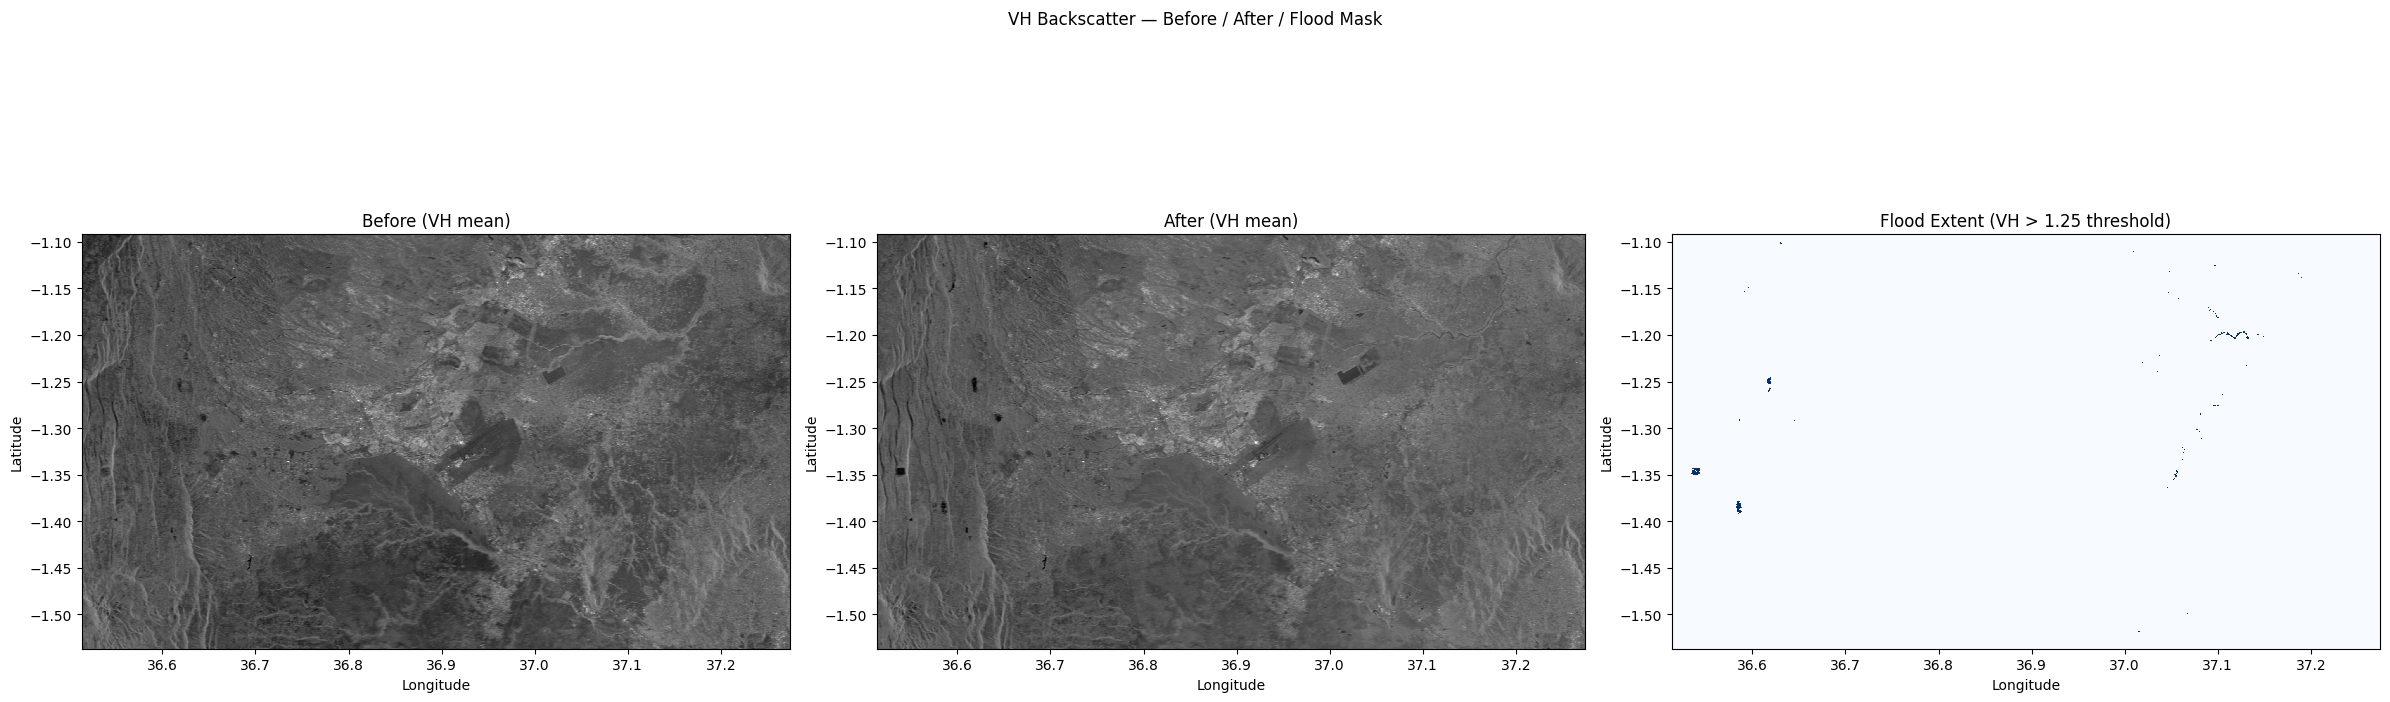

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

axes[0].imshow(before_mean.vh.compute().values, origin="upper", extent=extent, cmap="gray", interpolation="none")
axes[0].set_title("Before (VH mean)")

axes[1].imshow(after_mean.vh.values, origin="upper", extent=extent, cmap="gray", interpolation="none")
axes[1].set_title("After (VH mean)")

axes[2].imshow(difference_binary.vh.values, origin="upper", extent=extent, cmap="Blues", interpolation="none")
axes[2].set_title("Flood Extent (VH > 1.25 threshold)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("VH Backscatter — Before / After / Flood Mask", y=1.02)
plt.tight_layout()
plt.show()


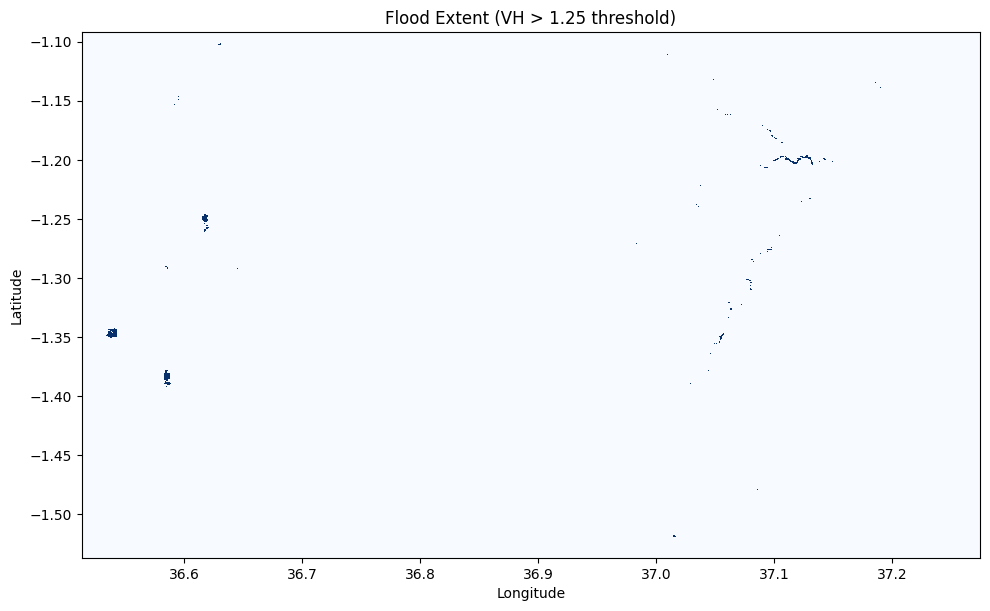

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    difference_binary.vh.values,
    origin="upper",
    extent=[
        difference_binary.longitude.min().item(),
        difference_binary.longitude.max().item(),
        difference_binary.latitude.min().item(),
        difference_binary.latitude.max().item(),
    ],
    cmap="Blues",
    interpolation="none",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Flood Extent (VH > 1.25 threshold)")
plt.tight_layout()
plt.show()

### Do the same using VV polarization and compare results.

In [47]:
# VV is already loaded and angle-corrected in dc; no need to reload from STAC
before_vv = dc.sel(time=slice("2024-03-06", "2024-04-06"))[["vv"]]
after_vv = dc.sel(time=slice("2024-05-01", "2024-06-01"))[["vv"]]

smoothed_before = xr.apply_ufunc(
    gaussian_filter1d,
    before_vv,
    kwargs={'sigma': 2, 'axis': list(before_vv.dims).index('time')},
    dask='parallelized'
)
smoothed_after = xr.apply_ufunc(
    gaussian_filter1d,
    after_vv,
    kwargs={'sigma': 2, 'axis': list(after_vv.dims).index('time')},
    dask='parallelized'
)

In [48]:
before_mean = smoothed_before.mean(dim="time").compute()
after_mean = smoothed_after.mean(dim="time").compute()

# dB difference: negative = backscatter decrease = open water / flooding
difference = after_mean - before_mean

difference_binary_vv = (difference < threshold).astype(int)

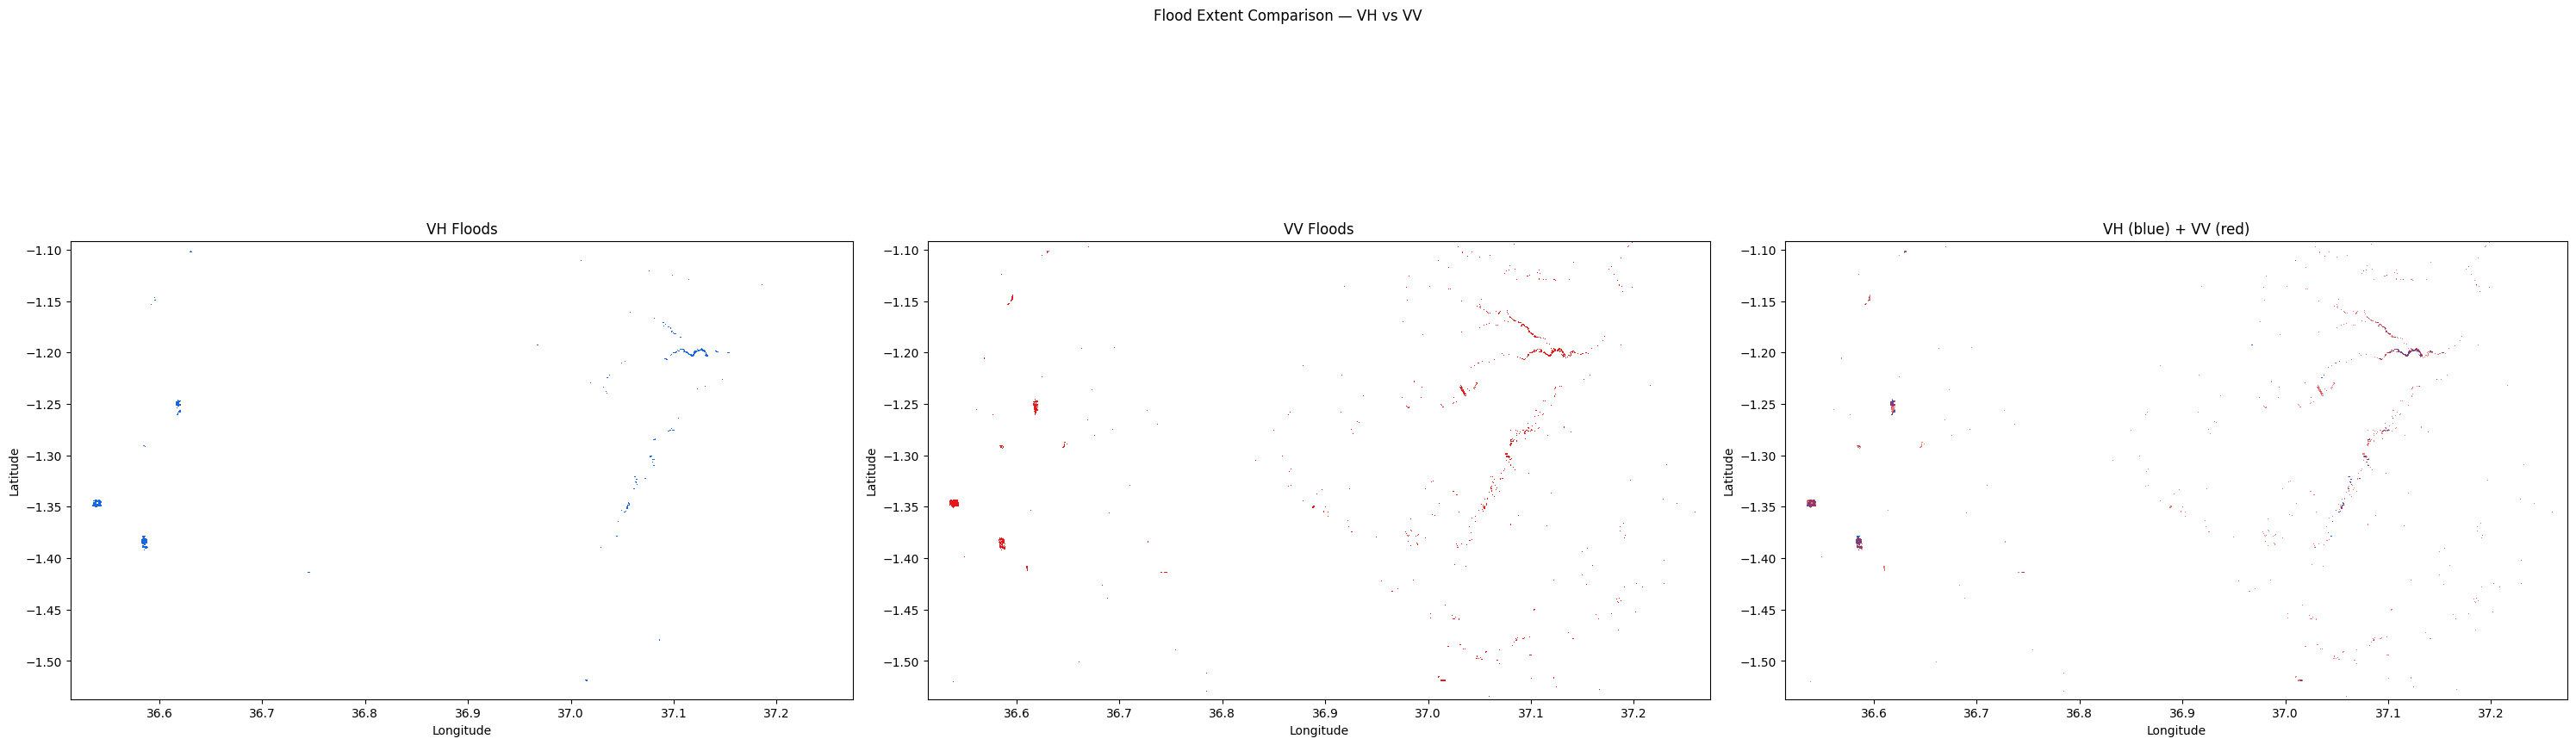

In [49]:
import numpy as np

extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

vh_data = difference_binary.vh.values
vv_data = difference_binary_vv.vv.values

def to_rgba(data, color_rgb):
    """Binary array → RGBA image. Flood pixels get color, zeros are transparent."""
    h, w = data.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    mask = data == 1
    rgba[mask, 0] = color_rgb[0]
    rgba[mask, 1] = color_rgb[1]
    rgba[mask, 2] = color_rgb[2]
    rgba[mask, 3] = 1.0  # fully opaque where flooded
    return rgba

vh_rgba = to_rgba(vh_data, (0.1, 0.4, 0.9))   # blue
vv_rgba = to_rgba(vv_data, (0.9, 0.1, 0.1))   # red

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[0].set_title("VH Floods")

axes[1].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none")
axes[1].set_title("VV Floods")

axes[2].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[2].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none", alpha=0.6)
axes[2].set_title("VH (blue) + VV (red)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Flood Extent Comparison — VH vs VV", y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# Ground truth flood polygons from Google Research.
# Place the file at: FinalProjects/data/groundsource_2026.parquet
groundtruth = gpd.read_parquet("data/groundsource__2026.parquet")


In [56]:
import pandas as pd
from shapely.geometry import box
groundtruth["start_date"] = pd.to_datetime(groundtruth["start_date"])
groundtruth["end_date"]   = pd.to_datetime(groundtruth["end_date"])
nairobi_box = box(lonmin, latmin, lonmax, latmax)
groundtruth = groundtruth[
    (groundtruth["area_km2"] > 5) &
    (groundtruth["area_km2"] <= 600)
    & (groundtruth.geometry.within(nairobi_box))
    & (groundtruth["start_date"].dt.year == 2024)
    
].copy()

print(groundtruth.shape)


(102, 5)


<Axes: xlabel='start_date'>

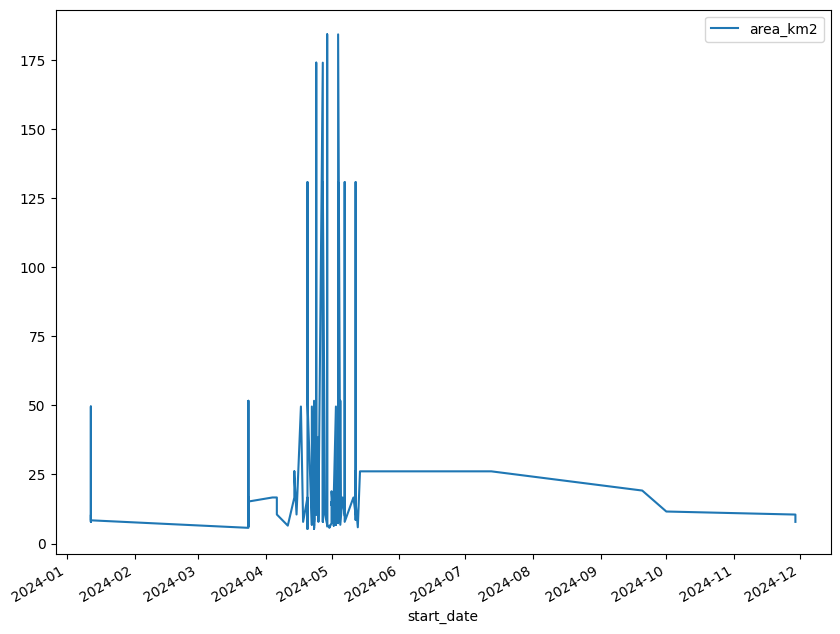

In [57]:
groundtruth.plot(kind="line", x="start_date", y="area_km2", figsize=(10, 8))

In [60]:
groundtruth.explore(column="area_km2", cmap="viridis", figsize=(10, 8))

ImportError: The 'folium>=0.12', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge "folium>=0.12" matplotlib mapclassify' or 'pip install "folium>=0.12" matplotlib mapclassify'.

In [59]:
extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

vh_data = difference_binary.vh.values
vv_data = difference_binary_vv.vv.values

def to_rgba(data, color_rgb):
    """Binary array → RGBA image. Flood pixels get color, zeros are transparent."""
    h, w = data.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    mask = data == 1
    rgba[mask, 0] = color_rgb[0]
    rgba[mask, 1] = color_rgb[1]
    rgba[mask, 2] = color_rgb[2]
    rgba[mask, 3] = 1.0  # fully opaque where flooded
    return rgba

vh_rgba = to_rgba(vh_data, (0.1, 0.4, 0.9))   # blue
vv_rgba = to_rgba(vv_data, (0.9, 0.1, 0.1))   # red

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[0].set_title("VH Floods")
groundtruth.plot(
    ax=axes[0], facecolor="none", edgecolor="green", linewidth=2, label="Forest"
)

axes[1].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none")
axes[1].set_title("VV Floods")

axes[2].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[2].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none", alpha=0.6)
axes[2].set_title("VH (blue) + VV (red)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Flood Extent Comparison — VH vs VV", y=1.02)
plt.tight_layout()
plt.show()

Exception: WarpOperationError('Chunk and warp failed')

In [ ]:
extent = [
    difference_binary.longitude.min().item(),
    difference_binary.longitude.max().item(),
    difference_binary.latitude.min().item(),
    difference_binary.latitude.max().item(),
]

vh_data = difference_binary.vh.values
vv_data = difference_binary_vv.vv.values

def to_rgba(data, color_rgb):
    """Binary array → RGBA image. Flood pixels get color, zeros are transparent."""
    h, w = data.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    mask = data == 1
    rgba[mask, 0] = color_rgb[0]
    rgba[mask, 1] = color_rgb[1]
    rgba[mask, 2] = color_rgb[2]
    rgba[mask, 3] = 1.0  # fully opaque where flooded
    return rgba

vh_rgba = to_rgba(vh_data, (0.1, 0.4, 0.9))   # blue
vv_rgba = to_rgba(vv_data, (0.9, 0.1, 0.1))   # red

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[0].set_title("VH Floods")
groundtruth.plot(
    ax=axes[0], facecolor="none", edgecolor="green", linewidth=2, label="Forest"
)

axes[1].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none")
axes[1].set_title("VV Floods")

axes[2].imshow(vh_rgba, origin="upper", extent=extent, interpolation="none")
axes[2].imshow(vv_rgba, origin="upper", extent=extent, interpolation="none", alpha=0.6)
axes[2].set_title("VH (blue) + VV (red)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Flood Extent Comparison — VH vs VV", y=1.02)
plt.tight_layout()
plt.show()

### Using Sentinel 1 Multi-Spectral Bands - Adding Deep Learning Approach

In [35]:
# Load all available Sentinel-2 bands for initial analysis
ALL_BANDS = [
    "scl",
    "red",
    "green",
    "blue",
    "nir",
    "swir16",
    "swir22",
    "rededge1",
    "rededge2",
    "rededge3",
]
dx = 0.0003  # ~30m resolution
epsg = 4326


# Temporal extent: April 2024
start_date = datetime(year=2024, month=3, day=6)
end_date = start_date + timedelta(days=92)

time_format = "%Y-%m-%d"
date_query = f"{start_date.strftime(time_format)}/{end_date.strftime(time_format)}"

stac_client = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")

nairobi_items = stac_client.search(
    bbox=bounds,
    collections=["sentinel-2-l2a"],
    datetime=date_query,
    query={"eo:cloud_cover": {"lt": 50}},
    limit=100,
).item_collection()

print(f"Nairobi: {len(nairobi_items)} scenes found")

nairobi_geobox = GeoBox.from_bbox(bounds, crs=f"epsg:{epsg}", resolution=dx)

dc_nairobi = odc.stac.load(
    nairobi_items,
    bands=ALL_BANDS,
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=nairobi_geobox,
    resampling="bilinear",
)
dc_nairobi

Nairobi: 34 scenes found


<xarray.Dataset> Size: 2GB
Dimensions:      (latitude: 1485, longitude: 2537, time: 34)
Coordinates:
  * latitude     (latitude) float64 12kB -1.092 -1.092 -1.092 ... -1.537 -1.537
  * longitude    (longitude) float64 20kB 36.51 36.51 36.51 ... 37.27 37.27
  * time         (time) datetime64[ns] 272B 2024-03-08T08:00:16.437000 ... 20...
    spatial_ref  int32 4B 4326
Data variables:
    scl          (time, latitude, longitude) uint8 128MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    red          (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    nir          (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    swir16       (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    swir22       (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge1     (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge2     (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge3     (time, latitude, longitude) uint16 256MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

In [45]:
def is_valid_pixel(data):
    """Include vegetated, not_vegetated, water, and snow pixels (SCL classes 4-6 and 11)."""
    return ((data > 3) & (data < 7)) | (data == 11)


valid_mask = is_valid_pixel(dc_nairobi.scl)
dc_valid = dc_nairobi.where(valid_mask)

all_median = (
    dc_valid[["red", "green", "blue", "nir"]]
    .to_dataarray(dim="band")
    .median(dim="time")
    .compute()
)

rgb_median = all_median.sel(band=["red", "green", "blue"])
fc_median = all_median.sel(band=["nir", "green", "blue"])

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
rgb_median.plot.imshow(ax=axes1[0], robust=True)
axes1[0].set_title(
    f"RGB Composite\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
axes1[0].set_aspect("equal")

fc_median.plot.imshow(ax=axes1[1], robust=True)
axes1[1].set_title("False Color (NIR-G-B)")
axes1[1].set_aspect("equal")

plt.tight_layout()

Task exception was never retrieved
future: <Task finished name='Task-3510724' coro=<Client._gather.<locals>.wait() done, defined at /Users/kknox/Documents/musa-650/musa-650-spring2026-Projects/FinalProjects/.venv/lib/python3.13/site-packages/distributed/client.py:2399> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/kknox/Documents/musa-650/musa-650-spring2026-Projects/FinalProjects/.venv/lib/python3.13/site-packages/distributed/client.py", line 2408, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

Correlations Analysis of Band within Nairobi over the Rainy and flood season

In [ ]:
# All spectral bands (excluding SCL) for correlation analysis
ALL_FEATURE_BANDS = ["green",  "swir16"]

# Compute median for all bands
all_bands_median = dc_valid[ALL_FEATURE_BANDS].median(dim="time").compute()

# Compute MNDWI
mndwi = (all_bands_median["green"] - all_bands_median["swir16"]) / (
    all_bands_median["green"] + all_bands_median["swir16"]
)

# Add indices to the dataset
all_bands_median["mndwi"] = mndwi
# Add SAR flood masks (extract DataArray from Dataset, align to optical grid)
all_bands_median["difference_binary_vh"] = difference_binary.vh.interp_like(all_bands_median, method="nearest")

all_bands_median["difference_binary_vv"] = difference_binary_vv.vv.interp_like(all_bands_median, method="nearest")


# Full feature list including indices
ALL_FEATURES = ALL_FEATURE_BANDS + ["mndwi", "difference_binary_vh", "difference_binary_vv"]



NameError: name 'difference_binary_vv' is not defined

### MNDWI Before / After Flood

MNDWI = (Green − SWIR16) / (Green + SWIR16). Positive values (blue) indicate open water; negative values (red) indicate vegetation or bare land. A positive shift in the difference map (After − Before) flags areas that became wetter or flooded.

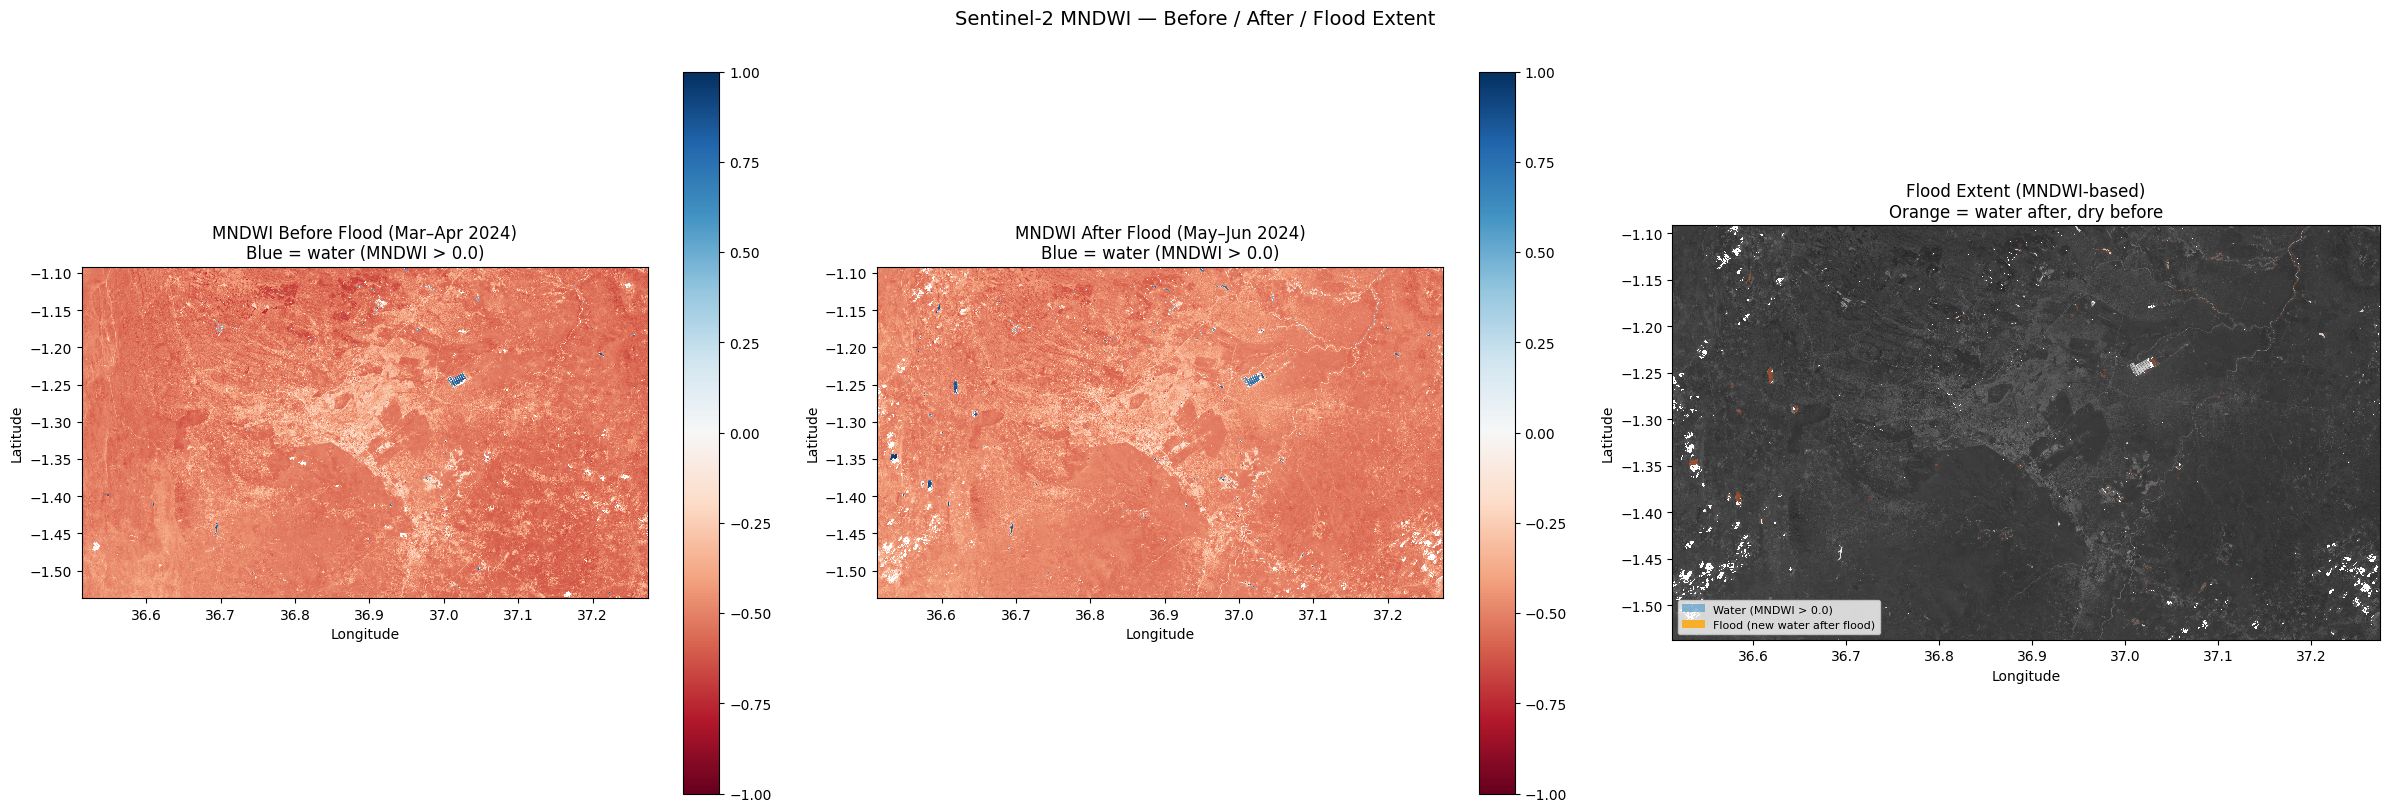

Water pixels before flood: 7,158
Water pixels after flood:  14,484
Newly flooded pixels:      8,343


In [40]:
# Sentinel-2 time windows matching the SAR before/after periods
before_s2 = dc_valid.sel(time=slice("2024-03-06", "2024-04-06"))
after_s2  = dc_valid.sel(time=slice("2024-05-01", "2024-06-01"))

# Median composites for each period
before_green  = before_s2["green"].median(dim="time").compute()
before_swir16 = before_s2["swir16"].median(dim="time").compute()
after_green   = after_s2["green"].median(dim="time").compute()
after_swir16  = after_s2["swir16"].median(dim="time").compute()

# MNDWI = (Green - SWIR16) / (Green + SWIR16)
mndwi_before = (before_green - before_swir16) / (before_green + before_swir16)
mndwi_after  = (after_green  - after_swir16)  / (after_green  + after_swir16)

# Threshold-based water masks: pixels above threshold are classified as water
mndwi_threshold = 0.0
water_before = mndwi_before > mndwi_threshold
water_after  = mndwi_after  > mndwi_threshold
flood        = water_after & (~water_before)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

mndwi_before.plot(ax=axes[0], cmap="RdBu", vmin=-1, vmax=1)
water_before.where(water_before).plot(
    ax=axes[0], cmap="Blues", vmin=0, vmax=1, add_colorbar=False, alpha=0.4
)
axes[0].set_title(f"MNDWI Before Flood (Mar–Apr 2024)\nBlue = water (MNDWI > {mndwi_threshold})")

mndwi_after.plot(ax=axes[1], cmap="RdBu", vmin=-1, vmax=1)
water_after.where(water_after).plot(
    ax=axes[1], cmap="Blues", vmin=0, vmax=1, add_colorbar=False, alpha=0.4
)
axes[1].set_title(f"MNDWI After Flood (May–Jun 2024)\nBlue = water (MNDWI > {mndwi_threshold})")

mndwi_after.plot(ax=axes[2], cmap="gray", add_colorbar=False)
flood.where(flood).plot(
    ax=axes[2], cmap="Oranges", vmin=0, vmax=1, add_colorbar=False, alpha=0.8
)
axes[2].set_title("Flood Extent (MNDWI-based)\nOrange = water after, dry before")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

legend_elements = [
    Patch(facecolor="#4393c3", alpha=0.6, label=f"Water (MNDWI > {mndwi_threshold})"),
    Patch(facecolor="orange",  alpha=0.8, label="Flood (new water after flood)"),
]
axes[2].legend(handles=legend_elements, loc="lower left", fontsize=8)

plt.suptitle("Sentinel-2 MNDWI — Before / After / Flood Extent", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Water pixels before flood: {int(water_before.sum()):,}")
print(f"Water pixels after flood:  {int(water_after.sum()):,}")
print(f"Newly flooded pixels:      {int(flood.sum()):,}")

As an eploratory phase, it maybe worth looking into correlation matrices for the flood extent 
variables.

In [ ]:
# Build flat coordinate arrays for every grid cell
lons = all_bands_median.longitude.values
lats = all_bands_median.latitude.values
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Spatial-join grid points against groundtruth polygons
grid_gdf = gpd.GeoDataFrame(
    {"lon": lon_grid.ravel(), "lat": lat_grid.ravel()},
    geometry=gpd.points_from_xy(lon_grid.ravel(), lat_grid.ravel()),
    crs="EPSG:4326",
)
inside = gpd.sjoin(grid_gdf, groundtruth[["geometry"]], how="inner", predicate="within")
inside = inside[~inside.index.duplicated()]

sample_lons = inside["lon"].values
sample_lats = inside["lat"].values

# Extract all features at the matched locations
X_all_bands = np.column_stack([
    all_bands_median[f]
    .sel(
        longitude=xr.DataArray(sample_lons, dims="points"),
        latitude=xr.DataArray(sample_lats, dims="points"),
        method="nearest",
    )
    .values
    for f in ALL_FEATURES
])


# Drop NaN samples
valid_samples_mask = ~np.isnan(X_all_bands).any(axis=1)
X_all_bands_clean = X_all_bands[valid_samples_mask]

# Correlation matrix
corr_matrix_full = np.corrcoef(X_all_bands_clean.T)
corr_df = pd.DataFrame(corr_matrix_full, index=ALL_FEATURES, columns=ALL_FEATURES)

# Plot heatmap
fig_corr_full, ax_corr_full = plt.subplots(figsize=(12, 10))
im_full = ax_corr_full.imshow(corr_matrix_full, cmap="RdBu_r", vmin=-1, vmax=1)
ax_corr_full.set_xticks(range(len(ALL_FEATURES)))
ax_corr_full.set_yticks(range(len(ALL_FEATURES)))
ax_corr_full.set_xticklabels(ALL_FEATURES, rotation=45, ha="right")
ax_corr_full.set_yticklabels(ALL_FEATURES)
plt.colorbar(im_full, ax=ax_corr_full, label="Correlation")
ax_corr_full.set_title("Feature Correlation Matrix (All Bands + Indices)")
plt.tight_layout()

NameError: name 'all_bands_median' is not defined

Mapping out the different Bands over the Ground Truth along with :
1) Measure of MNDWI
2) Measure of VV thresholded from SAR
3) Measure of VH thresholded from SAR

In [ ]:
import base64
import io

import folium
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def da_to_image_overlay(da, cmap, name, vmin=None, vmax=None, opacity=0.6):
    """Render a 2-D xarray DataArray as a folium ImageOverlay."""
    data = da.values.astype(float)
    vmin = vmin if vmin is not None else np.nanmin(data)
    vmax = vmax if vmax is not None else np.nanmax(data)

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = plt.get_cmap(cmap)(norm(data))  # H×W×4 float [0,1]

    # Binary layers: 0-pixels → transparent; continuous → NaN → transparent
    is_binary = np.isin(np.unique(data[~np.isnan(data)]), [0, 1]).all()
    rgba[..., 3] = np.where(data == 1, opacity, 0) if is_binary else np.where(np.isnan(data), 0, opacity)

    buf = io.BytesIO()
    Image.fromarray((rgba * 255).astype(np.uint8)).save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()

    return folium.raster_layers.ImageOverlay(
        image=f"data:image/png;base64,{b64}",
        bounds=[[float(da.latitude.min()), float(da.longitude.min())],
                [float(da.latitude.max()), float(da.longitude.max())]],
        name=name,
        opacity=1.0,  # alpha already baked into RGBA
        show=True,
    )


In [ ]:
m = groundtruth.explore(column="area_km2", name="Ground Truth",
    style_kwds={"fillOpacity": 0.4, "weight": 1},
)

# SAR-based flood masks
da_to_image_overlay(all_bands_median["difference_binary_vh"], "Blues", "SAR Flood VH binary").add_to(m)
da_to_image_overlay(all_bands_median["difference_binary_vv"], "Reds",  "SAR Flood VV binary", opacity=0.3).add_to(m)

# MNDWI layers
da_to_image_overlay(mndwi_after,          "RdBu",    "MNDWI After (May–Jun)",  vmin=-1,  vmax=1).add_to(m)
da_to_image_overlay(flood.astype(float),  "Oranges", "MNDWI Flood (threshold)", opacity=0.7).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

Below we consider the intersection between MNDWI pixels >0 and the VH or VV =1 Pixels

The goal here is to try an detect water using both indicators.

Intutively if the signal is true in both cases, perhaps this is a better measure of a flood extent

In [ ]:
# Intersection layers
flood_mndwi_vv = (
    (all_bands_median["mndwi"] > 0) & (all_bands_median["difference_binary_vv"] == 1)
).astype(int)

flood_mndwi_vh = (
    (all_bands_median["mndwi"] > 0) & (all_bands_median["difference_binary_vh"] == 1)
).astype(int)


In [ ]:
m = groundtruth.explore(
    name="Ground Truth",
    style_kwds={"fillOpacity": 0.1, "weight": 1},
)

da_to_image_overlay(flood_mndwi_vv, "Reds",   "MNDWI+ ∩ VV flood", opacity=0.8).add_to(m)
da_to_image_overlay(flood_mndwi_vh, "Blues",  "MNDWI+ ∩ VH flood", opacity=0.8).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m


Few paper examples:
<br>
<br>
https://www.sciencedirect.com/science/article/pii/S2666017225000094#sec3
<br>
<br>
Perhaps this paper that uses voting - https://www.nature.com/articles/s41598-026-41014-3    